# 03 - Von Heijne method: supporting example

**Aim:** build a small position-specific weight matrix and use it to score sequence windows.

This supporting notebook follows the six-context example before we implement the full method in the main section 03 notebook. This example uses eight positions (−6…−1,+1,+2); the project method will use 15 positions (−13…−1,+1,+2).

**Materials**
- `03-Methods-vonHeijne-2026.pdf` (slides 14–19; project method and evaluation in slides 12–13 and 20–25)
- `02c_data_analysis.ipynb` (section 2.2, fixed SwissProt background)


## 0. Load the example inputs

We define the six aligned contexts from slide 14 and reuse the SwissProt composition recorded in 02c. Normalizing the percentages gives background probabilities over the 20 canonical amino acids.


In [1]:
import numpy as np
import pandas as pd

contexts = [
    "STAAQAEP",
    "AVESSPIF",
    "LTVALAAE",
    "LSLSQSTN",
    "MIGVESVR",
    "SKPTRAFS",
]

amino_acids = "ACDEFGHIKLMNPQRSTVWY"
position_labels = ["-6", "-5", "-4", "-3", "-2", "-1", "+1", "+2"]
window_length = len(contexts[0])

swissprot_percent = {
    "A": 8.25, "C": 1.38, "D": 5.46, "E": 6.71, "F": 3.86,
    "G": 7.07, "H": 2.27, "I": 5.90, "K": 5.79, "L": 9.64,
    "M": 2.41, "N": 4.06, "P": 4.75, "Q": 3.93, "R": 5.52,
    "S": 6.66, "T": 5.36, "V": 6.85, "W": 1.10, "Y": 2.92,
}
background = np.array([swissprot_percent[aa] for aa in amino_acids])
background = background / background.sum()


## 1. Count residues at each position

Every cell starts with pseudocount 1 (slides 14–15). Each context then contributes one count per position. The matrix has amino acids as rows and motif positions as columns; slide 15 displays its transpose.


In [2]:
counts = np.ones((20, window_length))

for context in contexts:
    for position, aa in enumerate(context):
        counts[amino_acids.index(aa), position] += 1

pd.DataFrame(counts, index=list(amino_acids), columns=position_labels)


,-6,-5,-4,-3,-2,-1,+1,+2
A,2.0,1.0,2.0,3.0,1.0,4.0,2.0,1.0
C,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
D,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
E,1.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0
F,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0
G,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0
H,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
I,1.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0
K,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0
L,3.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0


## 2. Build the weight matrix

Each position contains six observations plus 20 pseudocounts, so we divide by 26 to obtain probabilities. We divide each amino acid's probability by its SwissProt background probability and take the natural logarithm (slides 14 and 16).

Positive weights indicate enrichment relative to the background; negative weights indicate depletion. With this small sample, pseudocounts can inflate the weights of rare residues (slide 17). We use the fixed background from 02c, so numerical scores may differ from the illustrative slide values.


In [3]:
probabilities = counts / (len(contexts) + 20)
# Reshape the background as a column to divide each amino-acid row by its frequency.
weights = np.log(probabilities / background[:, None])

pd.DataFrame(weights, index=list(amino_acids), columns=position_labels)


,-6,-5,-4,-3,-2,-1,+1,+2
A,-0.071093,-0.764240,-0.071093,0.334372,-0.764240,0.622054,-0.071093,-0.764240
C,1.023890,1.023890,1.023890,1.023890,1.023890,1.023890,1.023890,1.023890
D,-0.351476,-0.351476,-0.351476,-0.351476,-0.351476,-0.351476,-0.351476,-0.351476
E,-0.557626,-0.557626,0.135521,-0.557626,0.135521,-0.557626,0.135521,0.135521
F,-0.004694,-0.004694,-0.004694,-0.004694,-0.004694,-0.004694,0.688453,0.688453
G,-0.609887,-0.609887,0.083260,-0.609887,-0.609887,-0.609887,-0.609887,-0.609887
H,0.526193,0.526193,0.526193,0.526193,0.526193,0.526193,0.526193,0.526193
I,-0.428979,0.264168,-0.428979,-0.428979,-0.428979,-0.428979,0.264168,-0.428979
K,-0.410159,0.282988,-0.410159,-0.410159,-0.410159,-0.410159,-0.410159,-0.410159
L,0.178664,-0.919948,-0.226801,-0.919948,-0.226801,-0.919948,-0.919948,-0.919948


## 3. Score the first window

We sum the eight position-specific weights for the first window of the sequence from slide 18. All example residues belong to the canonical alphabet.


In [4]:
sequence = "MRFLAATFLLLALSTAAQAEPVQF"
window = sequence[:window_length]
score = 0

for position, aa in enumerate(window):
    score += weights[amino_acids.index(aa), position]

print("First window:", window)
print("Score:", score)


First window: MRFLAATF
Score: 0.7788697838369457


## 4. Scan the sequence

We repeat the same sum for every complete eight-residue window and keep the maximum (slide 19). Positions are reported starting from 1. The table lets us compare the windows; this toy example does not select a classification threshold or estimate predictive performance.


In [5]:
window_scores = []

for start in range(len(sequence) - window_length + 1):
    window = sequence[start:start + window_length]
    score = 0
    for position, aa in enumerate(window):
        score += weights[amino_acids.index(aa), position]
    window_scores.append({
        "start_position": start + 1,
        "window": window,
        "score": score,
    })

window_scores = pd.DataFrame(window_scores)
best_window = window_scores.loc[window_scores["score"].idxmax()]

print("Best window:", best_window["window"])
print("Start position:", best_window["start_position"])
print("Maximum score:", best_window["score"])
window_scores


Best window: STAAQAEP
Start position: 14
Maximum score: 3.891863342066688


,start_position,window,score
0,1,MRFLAATF,0.778870
1,2,RFLAATFL,-1.588254
2,3,FLAATFLL,-2.838944
3,4,LAATFLLL,-3.061051
4,5,AATFLLLA,-4.003955
5,6,ATFLLLAL,-2.367904
6,7,TFLLLALS,-1.866128
7,8,FLLLALST,-4.638717
8,9,LLLALSTA,-0.716132
9,10,LLALSTAA,-2.757648


### 4.1 Plot the score profile

Following slide 19, we plot one bar per window, ordered by its starting position. The orange bar marks the maximum score. The horizontal line marks zero log-odds, not a classification threshold.


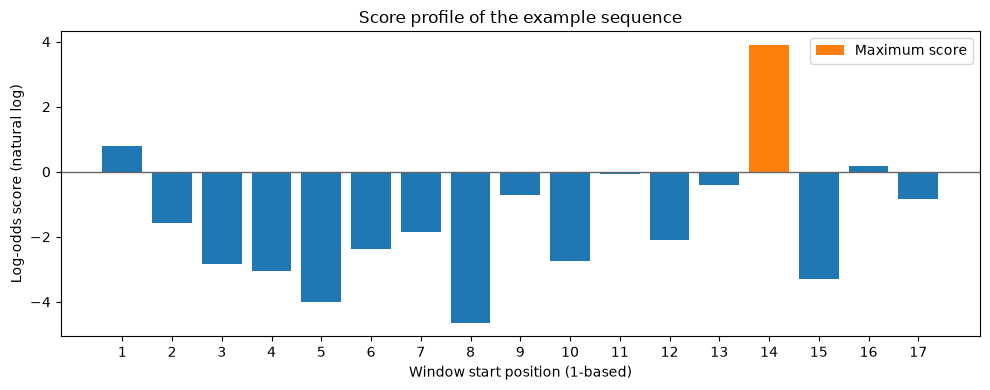

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(window_scores["start_position"], window_scores["score"], color="C0")
ax.bar(best_window["start_position"], best_window["score"],
       color="C1", label="Maximum score")
ax.axhline(0, color="0.4", linewidth=1)
ax.set_xticks(window_scores["start_position"])
ax.set_xlabel("Window start position (1-based)")
ax.set_ylabel("Log-odds score (natural log)")
ax.set_title("Score profile of the example sequence")
ax.legend()
fig.tight_layout()
plt.show()


## 5. Conclusions

The highest-scoring window is `STAAQAEP`, starting at position 14, with a score of approximately 3.892. The first window, `MRFLAATF`, scores approximately 0.779. The score profile shows how summing position-specific weights lets us compare candidate regions and select the best match to the learned motif.

Pseudocounts keep all probabilities nonzero, while the SwissProt background makes each weight describe enrichment or depletion relative to general amino-acid frequencies. This is a small demonstration: the best window is itself one of the six training contexts, so finding it does not demonstrate performance on unseen proteins. The example does not estimate a classification threshold.

### 5.1 Application to the project

This example illustrates the principles and algorithm we will use in the project, adapted to the representative datasets prepared in 02b and the cleavage-site contexts examined in 02c. We will replace the eight-residue toy contexts with 15-residue windows spanning −13…−1,+1,+2, retain pseudocount 1 and the SwissProt background, and score complete windows within the first 90 N-terminal residues of both positive and negative proteins (slides 12–13).

We will reuse the five training folds from 02b. In each round, three folds will supply the positive contexts used to estimate the matrix, one fold will select the threshold that maximizes validation F1 through the precision–recall curve, and one fold will evaluate the resulting classifier. Precision, Recall, Accuracy, MCC and F1 will be summarized as means with standard errors over the five rounds (slides 20–25). The independent benchmarking split will remain reserved. Handling non-canonical residues will be defined before applying the algorithm to the project sequences.
